# Regresión Logística 


El objetivo es predecir la clase del grano de arroz.

##### Bibliotecas necesarias

In [1]:
#General
import numpy as np
import pandas as pd
from skimpy import skim

#Graficas
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pandas.plotting import andrews_curves

#Valores atipicos
from pyod.models.knn import KNN


#Modelo de regresion logistica 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, make_scorer

### Carga de datos

Las 7 características morfológicas extraídas de cada grano de arroz son:

* Area: Número de píxeles dentro de los límites del grano de arroz.

* Perimeter: Circunferencia calculada midiendo la distancia entre píxeles alrededor de los límites del grano.
 
* Major_Axis_Length: Longitud de la línea más larga que se puede trazar sobre el grano, es decir, la distancia del eje principal.

* Minor_Axis_Length: Longitud de la línea más corta que se puede trazar sobre el grano, es decir, la distancia del eje menor.

* Eccentricity: Mide cuán redonda es la elipse que tiene los mismos momentos que el grano de arroz.

* Convex_Area: Número de píxeles del casco convexo más pequeño de la región formada por el grano.

* Extent: Proporción de la región formada por el grano en relación con el cuadro delimitador.

La variable objetivo (target) es Class, que indica la variedad del grano de arroz:

* Cammeo

* Osmancik

In [2]:
df = pd.read_csv(r"C:\Users\raulb\Desktop\Diplomado\Modulo2\Datos\Rice_Cammeo_Osmancik.csv")

In [3]:
df.sample(15)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
1430,14697,495.882996,208.158386,90.966873,0.899458,15073,0.594924,Cammeo
1438,13404,468.214996,191.548416,90.538300,0.881242,13804,0.706515,Cammeo
3370,10221,405.299988,168.633743,78.042610,0.886466,10368,0.602724,Osmancik
1818,13111,467.621002,193.567719,88.067871,0.890506,13456,0.619174,Osmancik
1071,13580,464.356995,190.380630,91.372269,0.877298,13781,0.627310,Cammeo
1377,14467,498.623993,213.595627,86.999992,0.913289,14857,0.740758,Cammeo
1316,12796,471.209015,203.929626,80.330009,0.919149,13022,0.684059,Cammeo
169,14209,496.272003,208.822906,87.758034,0.907408,14667,0.565735,Cammeo
3313,12495,454.792999,186.776627,86.492714,0.886316,12774,0.750315,Osmancik
187,15252,501.332001,207.524048,94.273094,0.890861,15595,0.591713,Cammeo


In [4]:
df["Class"] = df["Class"].astype("category")

In [5]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 3810   │ │ float64     │ 5     │ │ Class                 │                                │
│ │ Number of columns │ 8      │ │ int64       │ 2     │ └───────────────────────┘                                │
│ └───────────────────┴────────┘ │ category    │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column              ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Area                │   0 │     0 │   12670 │    1732 │   7551 │  11370 │  12420 │  13950 │ 18910 │  ▅▇▅▂  │  │
│ │ Perimeter           │   0 │     0 │   454.2 │    35.6 │  359.1 │  426.1 │  448.9 │  483.7 │ 548.4 │  ▅▇▅▅▁ │  │
│ │ Major_Axis_Length   │   0 │     0 │   188.8 │   17.45 │  145.3 │  174.4 │  185.8 │  203.6 │   239 │ ▁▇▇▇▅  │  │
│ │ Minor_Axis_Length   │   0 │     0 │   86.31 │    5.73 │  59.53 │  82.73 │  86.43 │  90.14 │ 107.5 │  ▁▃▇▂  │  │
│ │ Eccentricity        │   0 │     0 │  0.8869 │ 0.02082 │ 0.7772 │ 0.8724 │ 0.8891 │ 0.9026 │ 0.948 │   ▂▇▇▁ │  │
│ │ Convex_Area         │   0 │     0 │   12950 │    1777 │   7723 │  11630 │  12710 │  14280 │ 19100 │  ▅▇▅▂  │  │
│ │ Extent              │   0 │     0 │  0.6619 │ 0.07724 │ 0.4974 │ 0.5989 │ 0.6454 │ 0.7266 │ 0.861 │ ▁▇▆▅▅▁ │  │
│ └─────────────────────┴─────┴───────┴─────────┴─────────┴────────┴────────┴────────┴────────┴───────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                 ┃ NA         ┃ NA %             ┃ ordered                   ┃ unique                ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Class                  │          0 │                0 │ False                     │                     2 │  │
│ └────────────────────────┴────────────┴──────────────────┴───────────────────────────┴───────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

## Analisis Exploratorio de los Datos 

In [6]:
#Variables numericas y categoricas
var_cat = ["Class"]
var_num = list(set(df.columns) - set(var_cat))

In [7]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#008080"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#00a77d", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values, textinfo='percent+label')]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self):
        corr_matrix = self.df[self.num_vars].corr()

        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='Viridis'))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [8]:
analisis = analyze(df, var_num, var_cat)

In [9]:
analisis.plot_num()

In [10]:
analisis.plot_cat()

In [11]:
analisis.corr_matrix()

In [12]:
#Curva de Andrews
def andrews_curve(df, cat_col): 
    plt.figure(figsize=(12,8))
    andrews_curves(df, cat_col, colormap= "Set2", alpha=0.5)
    plt.title('Curvas de Andrews')
    plt.xlabel('t (función de Fourier)')
    plt.ylabel('Valor transformado')
    plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
    plt.show()

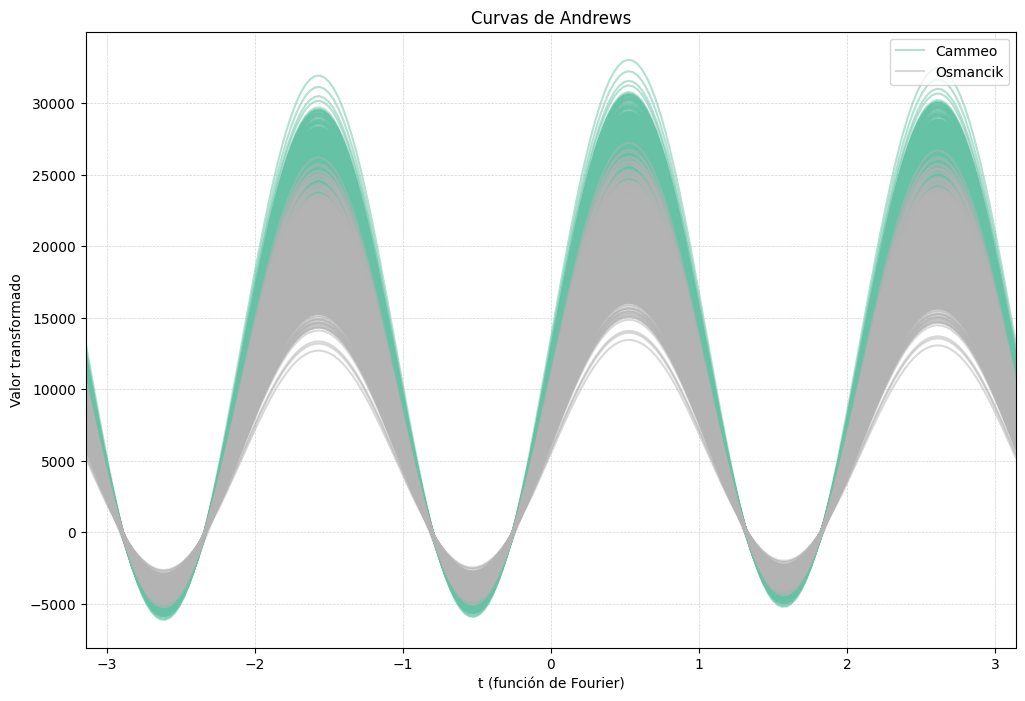

In [13]:
andrews_curve(df, "Class")

In [14]:
def plot_by_cat(df, var_num, var_cat):
    for var in var_num:
        fig, axes = plt.subplots(1, 2, figsize=(12,5))
        
        # Boxplot
        sns.boxplot(x=var_cat, y=var, data=df, ax=axes[0], palette="viridis")
        axes[0].set_title(f"{var}")
        axes[0].tick_params(axis='x', rotation=45)
        
        # Densidad
        sns.kdeplot(data=df, x=var, hue=var_cat, fill=True, alpha=0.4, palette = "viridis", ax=axes[1])
        axes[1].set_title(f"{var}")
        
        plt.tight_layout()
        plt.show()

C:\Users\raulb\AppData\Local\Temp\ipykernel_26592\3072398405.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




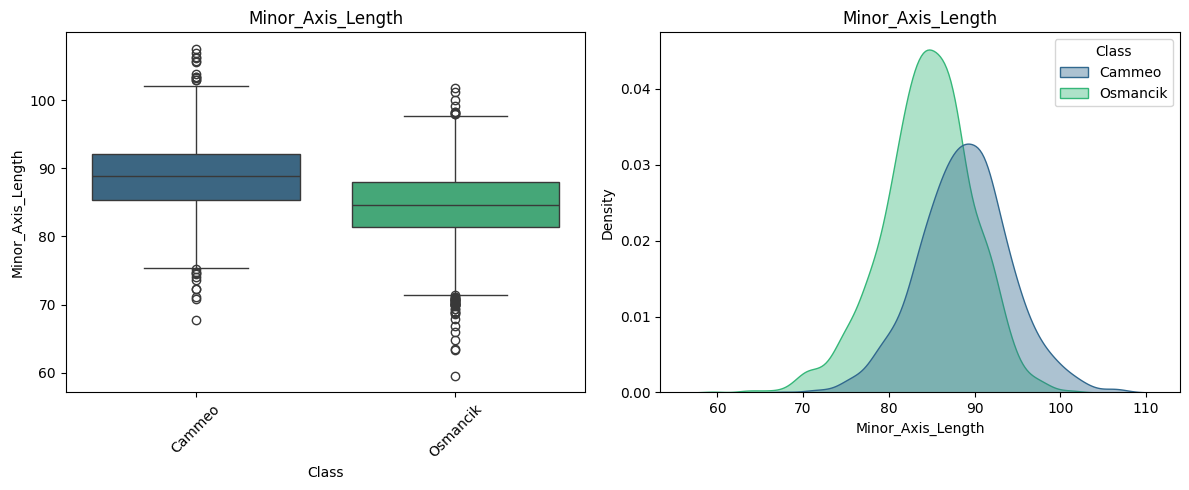

C:\Users\raulb\AppData\Local\Temp\ipykernel_26592\3072398405.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




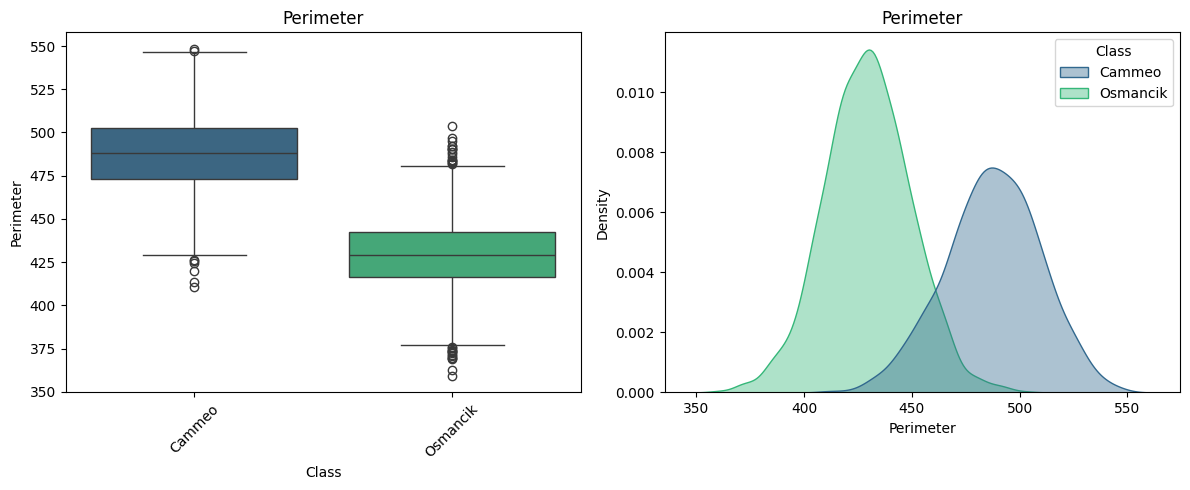

C:\Users\raulb\AppData\Local\Temp\ipykernel_26592\3072398405.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




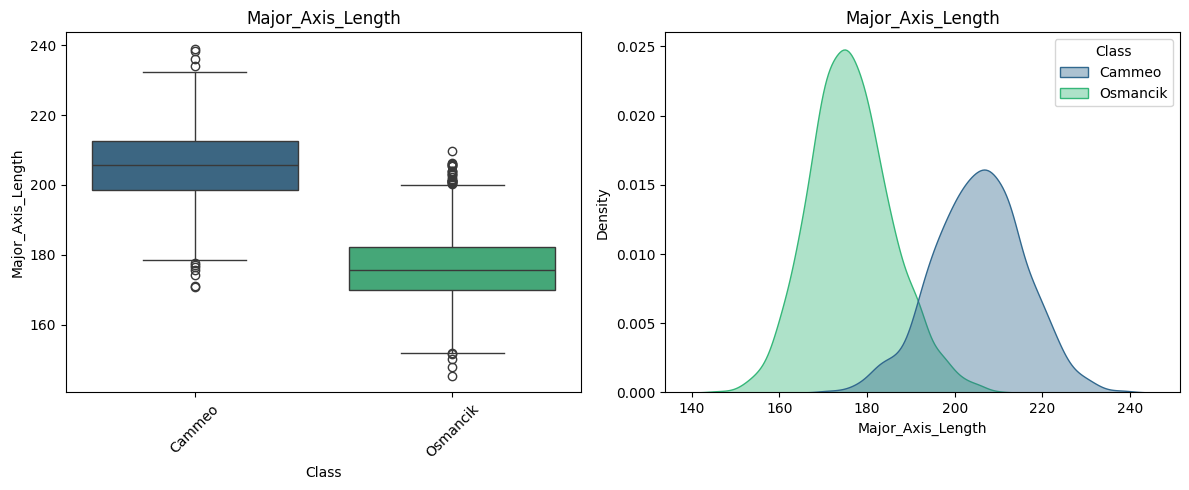

C:\Users\raulb\AppData\Local\Temp\ipykernel_26592\3072398405.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




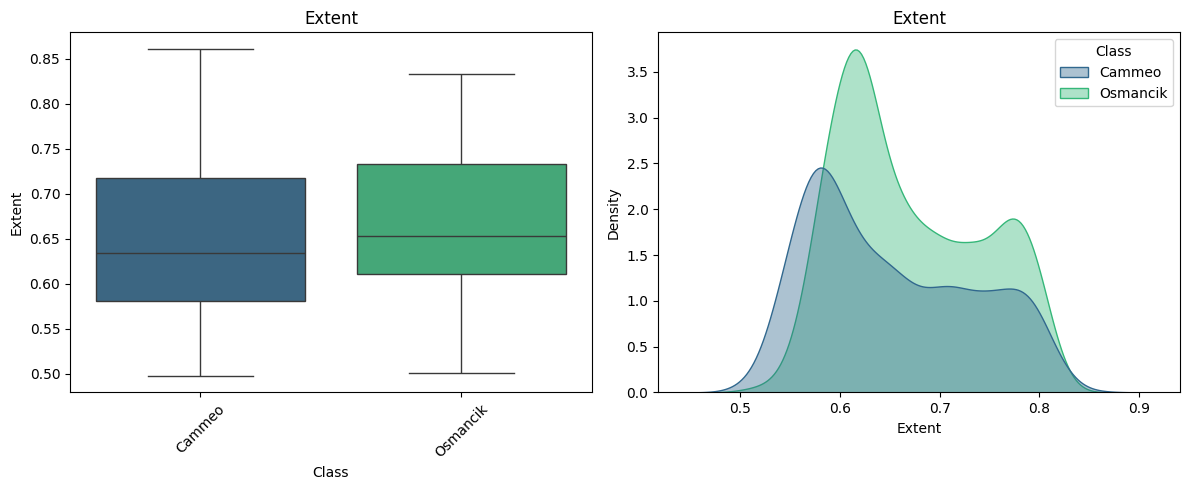

C:\Users\raulb\AppData\Local\Temp\ipykernel_26592\3072398405.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




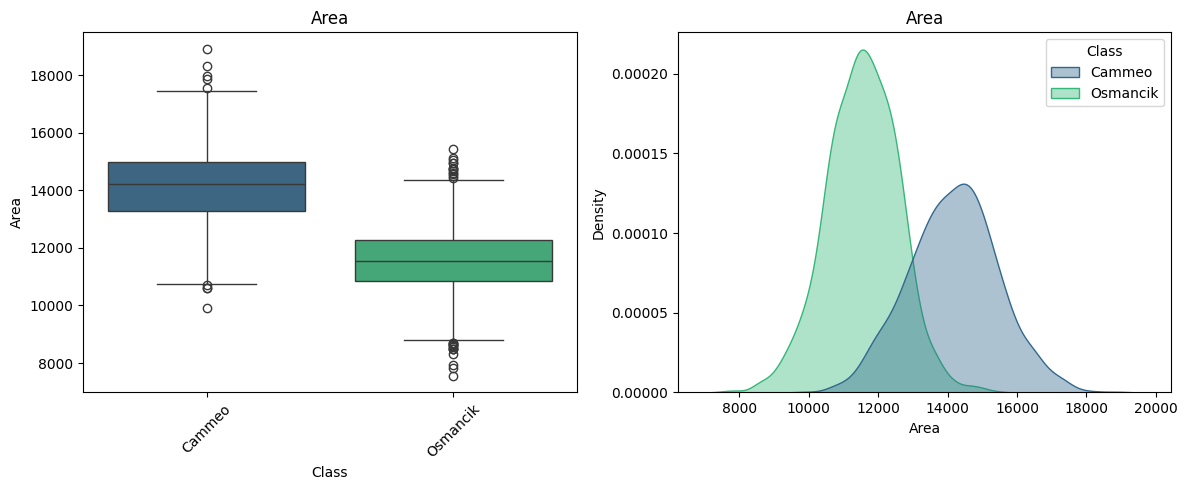

C:\Users\raulb\AppData\Local\Temp\ipykernel_26592\3072398405.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




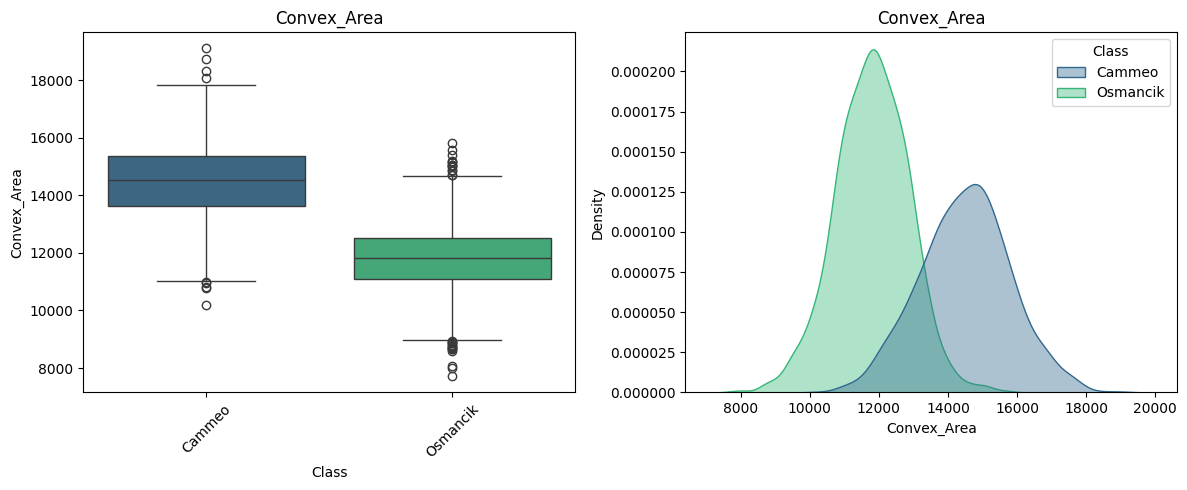

C:\Users\raulb\AppData\Local\Temp\ipykernel_26592\3072398405.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




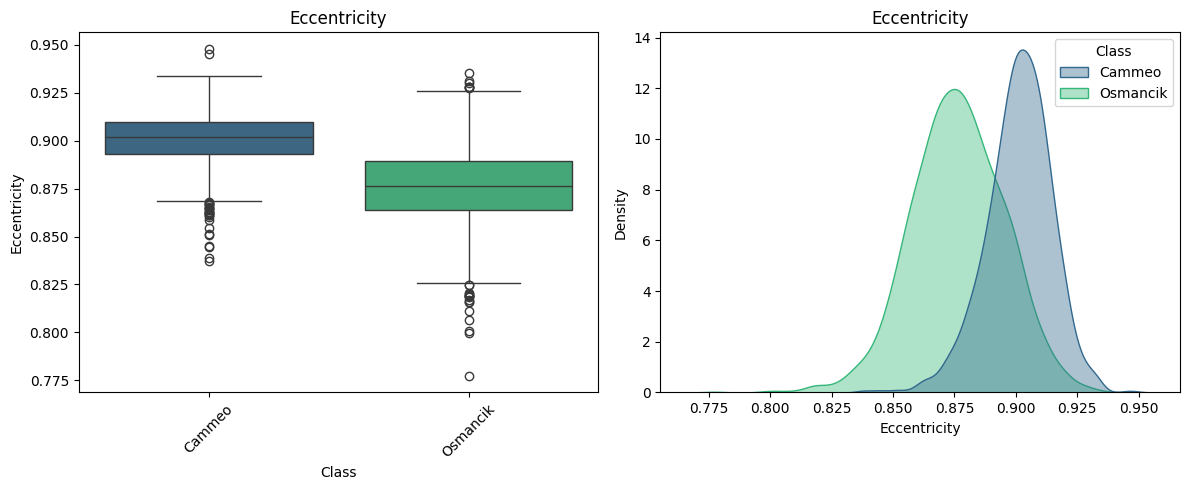

In [15]:
plot_by_cat(df, var_num, "Class")

### Valores atipicos

In [16]:
#Usamos isolation Forest
def outliers_knn(df, n_neighbors=5, method='largest', contamination=0.01):
    model = KNN(n_neighbors=n_neighbors, method=method, contamination=contamination)
    model.fit(df)
    preds = model.predict(df)
    return df[preds == 1]

In [17]:
df_outliers = outliers_knn(df[var_num])

In [18]:
df.loc[df_outliers.index]

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
145,16835,522.534973,216.271652,100.432510,0.885635,17404,0.735217,Cammeo
173,17082,548.445984,230.188721,95.757584,0.909366,17576,0.592467,Cammeo
181,14806,509.376007,214.142426,89.691704,0.908059,15594,0.708794,Cammeo
198,15569,528.789001,221.576843,90.982384,0.911810,16286,0.565693,Cammeo
247,16734,531.507019,220.695480,97.839333,0.896362,17242,0.657111,Cammeo
277,17948,526.918030,214.093826,107.542450,0.864685,18322,0.666370,Cammeo
331,12720,472.234009,201.640854,82.228416,0.913073,13352,0.745080,Cammeo
360,17353,539.033997,220.961197,101.454102,0.888359,17845,0.630308,Cammeo
425,13682,488.899994,199.559692,89.442215,0.893934,14457,0.599667,Cammeo
573,16059,522.723999,217.850143,95.153885,0.899565,16675,0.688459,Cammeo


In [19]:
df.loc[df_outliers.index]["Class"].value_counts(normalize = False)

Class
Cammeo      21
Osmancik    12
Name: count, dtype: int64

In [20]:
df.drop(df_outliers.index, inplace=True)

In [21]:
df

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo
...,...,...,...,...,...,...,...,...
3805,11441,415.858002,170.486771,85.756592,0.864280,11628,0.681012,Osmancik
3806,11625,421.390015,167.714798,89.462570,0.845850,11904,0.694279,Osmancik
3807,12437,442.498993,183.572922,86.801979,0.881144,12645,0.626739,Osmancik
3808,9882,392.296997,161.193985,78.210480,0.874406,10097,0.659064,Osmancik


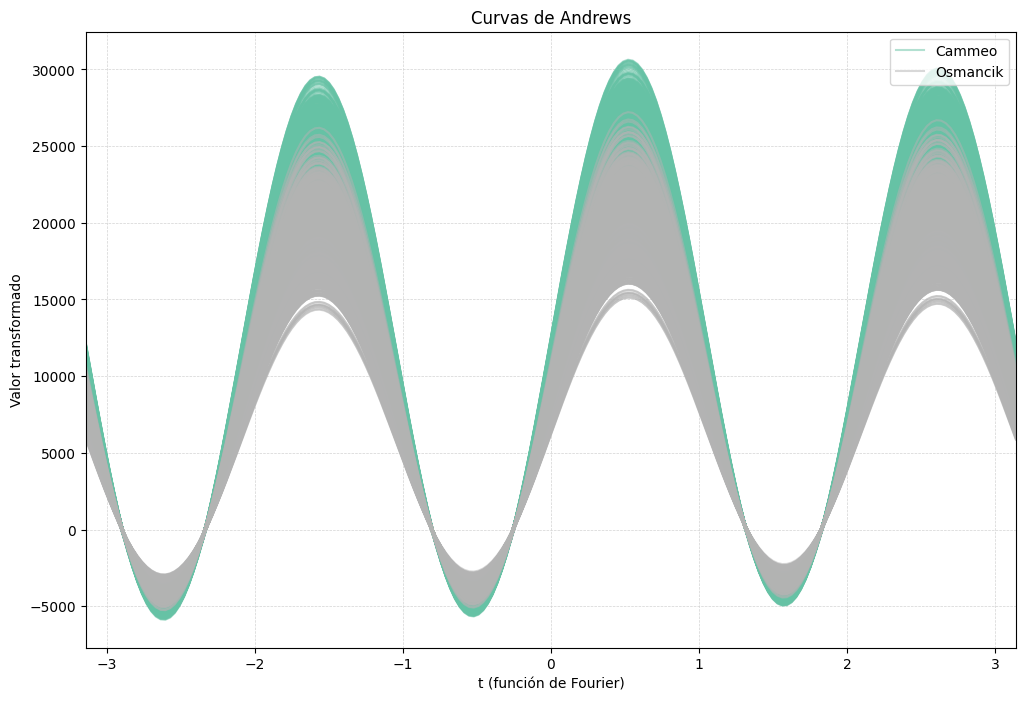

In [22]:
andrews_curve(df, "Class")

De lo anterior podemos concluir:
* Existe multicolinealidad, ya que todos son medidas con respecto al área de una "elipse".
* Removimos valores atípicos al estar claramente lejados de los demás. 
* Existen diferencias visibles entre los datos por clase.
* No hay valores ausentes.
* La variable objetivo no está perfectamente balanceada, pero no es tan fuerte como para aplicar métodos de sobremuestreo o stratify.

## Modelado

#### Split, codificacion y escalamiento

In [23]:
#Codificamos en 1 si Osmancik, 0 e.o.c.
df["Class"] = df["Class"].map(lambda x: 1 if x == "Osmancik" else 0)

In [24]:
df

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,0
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,0
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,0
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,0
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,0
...,...,...,...,...,...,...,...,...
3805,11441,415.858002,170.486771,85.756592,0.864280,11628,0.681012,1
3806,11625,421.390015,167.714798,89.462570,0.845850,11904,0.694279,1
3807,12437,442.498993,183.572922,86.801979,0.881144,12645,0.626739,1
3808,9882,392.296997,161.193985,78.210480,0.874406,10097,0.659064,1


In [25]:
vars = ["Major_Axis_Length", "Perimeter", 'Convex_Area', 'Eccentricity']

y = df["Class"]
X = df[vars]

#### Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 1989)

#### Escalamiento

In [27]:
scaler = MinMaxScaler()

#Ajustamos solo con train
scaler.fit(X_train)

#Transformar train y test
X_train[vars] = scaler.fit_transform(X_train[vars])
X_test[vars] = scaler.transform(X_test[vars])

### Regresion Logistica

In [28]:
class LogisticModel:
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test

        self.model = None
        self.y_pred_train = None
        self.y_pred_test = None
        self.proba_train = None
        self.proba_test = None

    # Ajuste del modelo
    def fit_model(self, **kwargs):
        self.model = LogisticRegression(**kwargs)
        self.model.fit(self.X_train, self.y_train)

        # Guardamos predicciones y probabilidades
        self.proba_train = self.model.predict_proba(self.X_train)[:,1]
        self.proba_test  = self.model.predict_proba(self.X_test)[:,1]

        self.y_pred_train = self.model.predict(self.X_train)
        self.y_pred_test  = self.model.predict(self.X_test)
        return self.model

    # Coeficientes del modelo
    def coefs(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_model()")
        coef_names = ["intercept"] + list(self.X_train.columns)
        coefs = [self.model.intercept_[0]] + list(self.model.coef_[0])
        return pd.DataFrame({"Vars": coef_names, "Coef": coefs}).set_index("Vars")

    # Métricas de desempeño
    def performance(self):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_model()")

        def calc_metrics(y_true, y_pred, proba):
            acc = accuracy_score(y_true, y_pred)
            sens = recall_score(y_true, y_pred)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            spec = tn / (tn + fp)
            auc = roc_auc_score(y_true, proba)
            return acc, sens, spec, auc

        metrics_train = calc_metrics(self.y_train, self.y_pred_train, self.proba_train)
        metrics_test  = calc_metrics(self.y_test, self.y_pred_test, self.proba_test)

        df_perf = pd.DataFrame({
            "Metrica": ["Accuracy", "Sensibilidad", "Especificidad", "AUC"],
            "Train": metrics_train,
            "Test": metrics_test
        })
        return df_perf

    # Curva ROC
    def plot_roc(self):
        if self.proba_test is None:
            raise ValueError("Primero ajusta el modelo con fit_model() para calcular probabilidades")

        fpr, tpr, thresholds = roc_curve(self.y_test, self.proba_test)
        auc_score = roc_auc_score(self.y_test, self.proba_test)

        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.3f})')
        plt.plot([0,1], [0,1], color='gray', linestyle='--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Curva ROC")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

    # Cross-validation con AUC
    def cross_auc(self, cv=4):
        if self.model is None:
            raise ValueError("Primero ajusta el modelo con fit_model()")

        auc_scorer = make_scorer(roc_auc_score, needs_proba=True)
        scores = cross_val_score(self.model, self.X_train, self.y_train,
                                 cv=cv, scoring=auc_scorer, n_jobs=-1)

        stats = {
            "media": np.round(np.mean(scores),4),
            "mediana": np.round(np.median(scores),4),
            "desv_est": np.round(np.std(scores, ddof=1),4)
        }
        return stats

In [29]:
#Instanciamos
reglog = LogisticModel(X_train, X_test, y_train, y_test)

In [30]:
#Ajustamos y entrenamos
reglog.fit_model(max_iter = 1000)

LogisticRegression(max_iter=1000)

In [31]:
#Coeficientes
reglog.coefs()

,Coef
Vars,
intercept,11.707013
Major_Axis_Length,-7.160879
Perimeter,-5.632221
Convex_Area,-4.581632
Eccentricity,-4.917312


In [32]:
#Cross Validation
reglog.cross_auc(cv = 5)

c:\Users\raulb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py:548: FutureWarning:

The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.



{'media': np.float64(0.9775),
 'mediana': np.float64(0.9779),
 'desv_est': np.float64(0.0051)}

In [33]:
#Rendimiento
reglog.performance()

,Metrica,Train,Test
0,Accuracy,0.928869,0.926808
1,Sensibilidad,0.943159,0.943511
2,Especificidad,0.909735,0.903967
3,AUC,0.977722,0.979059


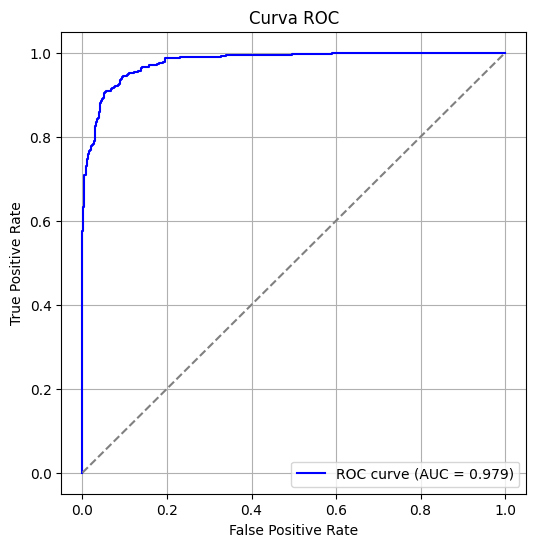

In [34]:
#Curva AUC
reglog.plot_roc()